# Day 02 — Fourier Intuition and STFT

**Learn block summary (defensible without derivations):**

- **Frequency, phase, harmonics, spectral energy.** Any signal is a sum of sinusoids; the Fourier transform reports how much energy sits at each frequency. Phase encodes *where* each sinusoid's peaks sit in time — invisible in a magnitude spectrogram, but it is what reconstruction (e.g. TTS vocoders) needs. Harmonics are integer multiples of a fundamental: voiced speech shows them as horizontal stripes, with formants (vocal-tract resonances) as brighter bands layered on top.
- **STFT mechanics.** Slide a window of `n_fft` samples across the waveform every `hop_length` samples, FFT each window. Overlap (window > hop) prevents energy at frame boundaries from being missed or chopped.
- **The tradeoff, quantitatively.** Frequency resolution is Δf = sr / n_fft; time resolution is Δt = hop / sr. A longer window resolves closer frequencies but blurs *when* things happen; a shorter window pins events in time but smears frequencies together. Window choice sets the ceiling on both; hop only sets how densely that ceiling is sampled.
- **The speech standard.** At 16 kHz, 25 ms window / 10 ms hop (n_fft=400, hop=160): 25 ms is long enough to resolve formant structure (~40 Hz bins) yet short enough to keep plosive onsets visible; 10 ms matches phoneme transition rates. This is the configuration ASR features (Week 1's log-Mel work) build on.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

REPO = Path("..").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.audio.loader import load_audio
from src.audio.stft import (
    DEFAULT_HOP_16K,
    DEFAULT_N_FFT_16K,
    spectrogram_db,
    stft_resolutions,
)

wave, sr = load_audio(REPO / "data/clean_16k/clean_01.wav", target_sr=16000)
num_samples = wave.shape[-1]
duration = num_samples / sr
print(f"clean_01: {duration:.1f}s @ {sr} Hz, {num_samples} samples")

clean_01: 6.0s @ 16000 Hz, 96000 samples


{'window_ms': 25.0, 'hop_ms': 10.0, 'delta_t_ms': 10.0, 'delta_f_hz': 40.0, 'num_freq_bins': 201}


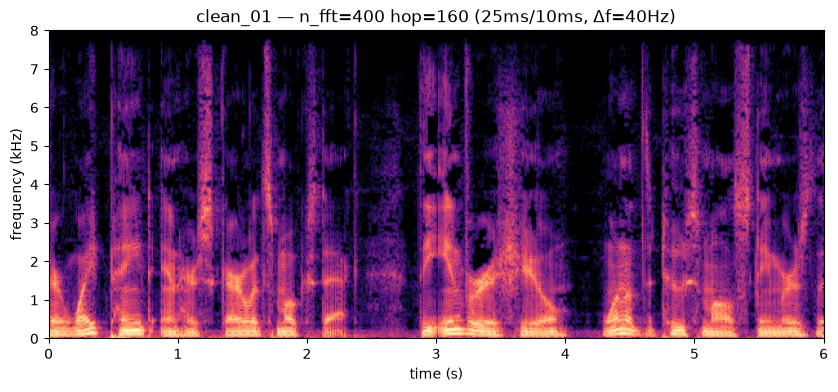

In [3]:
# The speech-standard configuration: 25 ms window, 10 ms hop.
res = stft_resolutions(DEFAULT_N_FFT_16K, DEFAULT_HOP_16K, sr)
spec = spectrogram_db(wave, n_fft=DEFAULT_N_FFT_16K, hop_length=DEFAULT_HOP_16K)
print(res)

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(spec, origin="lower", aspect="auto", extent=(0, duration, 0, sr / 2000),
          cmap="magma", vmin=-80, vmax=0)
ax.set_xlabel("time (s)"); ax.set_ylabel("frequency (kHz)")
ax.set_title(f"clean_01 — n_fft={DEFAULT_N_FFT_16K} hop={DEFAULT_HOP_16K} "
             f"(25ms/10ms, Δf={res['delta_f_hz']:.0f}Hz)")
plt.show()

## Experiment — one STFT setting varied at a time (audio held constant)

- **Row 1: window length varies** (16 → 128 ms) at fixed 75% overlap — the time/frequency resolution tradeoff.
- **Row 2: hop varies** (8 → 56 ms) at fixed 64 ms window — sampling density of a fixed ceiling.

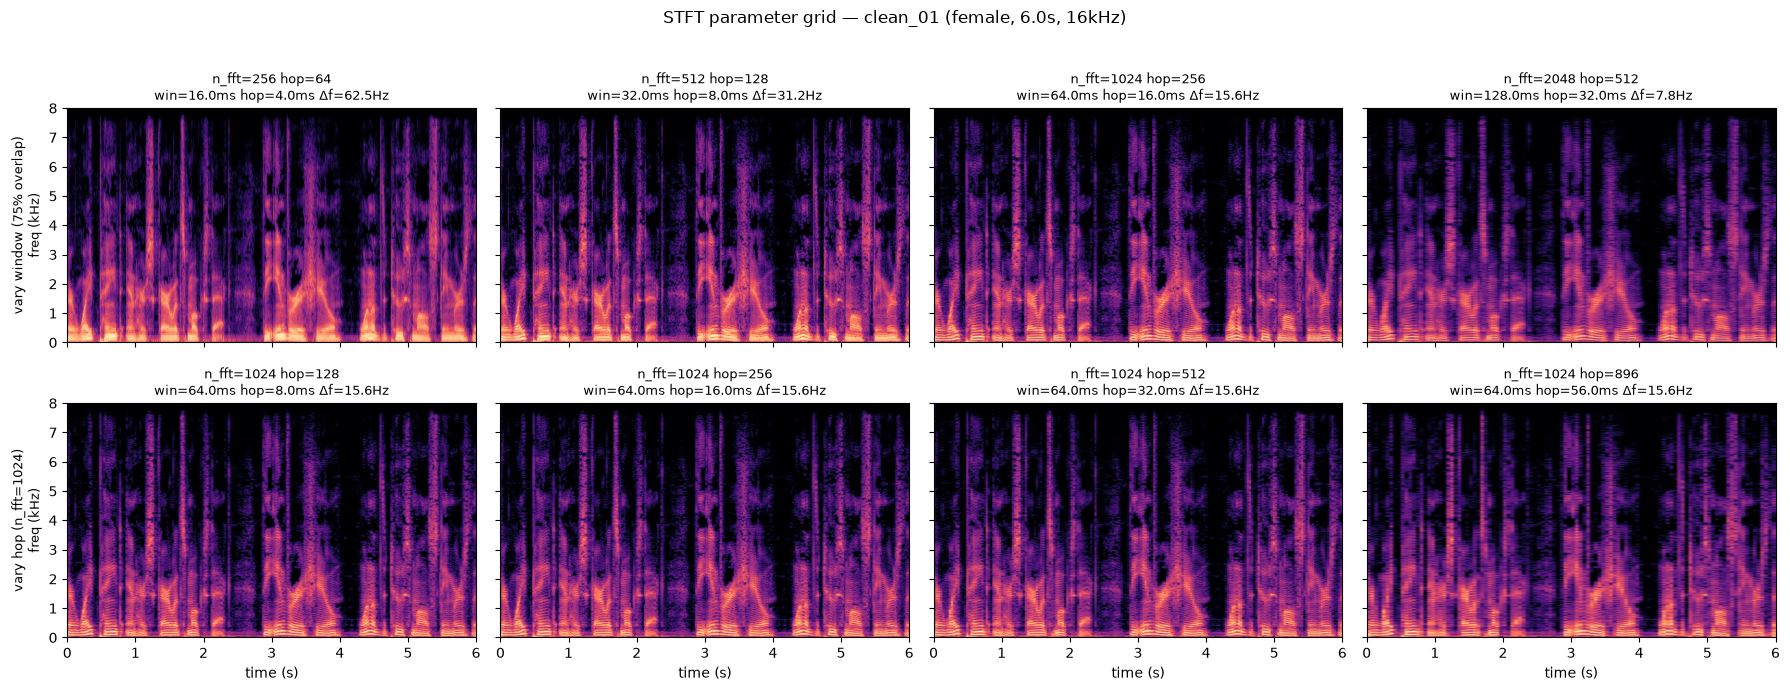

In [4]:
vary_window = [(256, 64), (512, 128), (1024, 256), (2048, 512)]   # 75% overlap
vary_hop = [(1024, h) for h in (128, 256, 512, 896)]               # fixed window
rows = [("vary window (75% overlap)", vary_window),
        ("vary hop (n_fft=1024)", vary_hop)]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, sharey=True)
for row_idx, (row_title, settings) in enumerate(rows):
    for col_idx, (n_fft, hop) in enumerate(settings):
        ax = axes[row_idx, col_idx]
        spec = spectrogram_db(wave, n_fft=n_fft, hop_length=hop)
        res = stft_resolutions(n_fft, hop, sr)
        ax.imshow(spec, origin="lower", aspect="auto",
                  extent=(0.0, duration, 0.0, sr / 2000), cmap="magma", vmin=-80, vmax=0)
        ax.set_title(f"n_fft={n_fft} hop={hop}\nwin={res['window_ms']:.1f}ms "
                     f"hop={res['hop_ms']:.1f}ms Δf={res['delta_f_hz']:.1f}Hz", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f"{row_title}\nfreq (kHz)", fontsize=9)
        if row_idx == 1:
            ax.set_xlabel("time (s)")
fig.suptitle(f"STFT parameter grid — clean_01 (female, {duration:.1f}s, 16kHz)")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(REPO / "results/day02_stft_parameter_grid.png", dpi=150)
plt.show()

In [5]:
for title, settings in rows:
    print(f"\n{title}:")
    for n_fft, hop in settings:
        r = stft_resolutions(n_fft, hop, sr)
        frames = 1 + wave.shape[-1] // hop
        print(f"  n_fft={n_fft:5d} hop={hop:4d} | win {r['window_ms']:6.1f}ms "
              f"| Δf {r['delta_f_hz']:6.1f}Hz | Δt {r['delta_t_ms']:5.1f}ms | {frames} frames")


vary window (75% overlap):
  n_fft=  256 hop=  64 | win   16.0ms | Δf   62.5Hz | Δt   4.0ms | 1501 frames
  n_fft=  512 hop= 128 | win   32.0ms | Δf   31.2Hz | Δt   8.0ms | 751 frames
  n_fft= 1024 hop= 256 | win   64.0ms | Δf   15.6Hz | Δt  16.0ms | 376 frames
  n_fft= 2048 hop= 512 | win  128.0ms | Δf    7.8Hz | Δt  32.0ms | 188 frames

vary hop (n_fft=1024):
  n_fft= 1024 hop= 128 | win   64.0ms | Δf   15.6Hz | Δt   8.0ms | 751 frames
  n_fft= 1024 hop= 256 | win   64.0ms | Δf   15.6Hz | Δt  16.0ms | 376 frames
  n_fft= 1024 hop= 512 | win   64.0ms | Δf   15.6Hz | Δt  32.0ms | 188 frames
  n_fft= 1024 hop= 896 | win   64.0ms | Δf   15.6Hz | Δt  56.0ms | 108 frames


## Observations — what becomes easier or harder to see

**Window length (row 1).** At 16 ms the vertical energy bursts of plosive consonants (t/k/p onsets) are crisp in time, but harmonic stripes blur together — Δf=62.5 Hz cannot separate harmonics of a 100–150 Hz fundamental spaced that far apart at low frequencies, and formant edges go soft. At 128 ms the harmonics and formant bands are cleanly resolved horizontal stripes (Δf=7.8 Hz), but onsets smear sideways by the window length — a plosive looks like a soft ramp instead of a click, and short pauses between words nearly vanish. Speech events of interest (phonemes ~50–200 ms, formants ~4 Hz-per-bin accuracy needs) sit between these extremes.

**Hop length (row 2).** Frequency detail is identical across the row (same window) — confirming hop sets temporal sampling only, not the resolution ceiling. Small hops oversample smoothly (751 frames at 8 ms, redundant but harmless, 2× the compute); the 56 ms hop starts skipping past short events entirely — the 64 ms window already blurs them, and coarse hopping makes the timeline choppy. Below the window limit, smaller hops add smoothness, not information.

## Completion check — choosing a configuration and defending it

For 16 kHz speech I choose **n_fft=400, hop=160 (25 ms / 10 ms)**: a 25 ms window yields Δf=40 Hz — fine enough to track formants while spanning ~2–3 pitch periods so voiced structure is stable within a frame — and 10 ms hops sample phoneme transitions densely without the 4× compute waste of 75%+ overlap. Shorter windows would blur the spectral detail ASR depends on; longer ones would hide the very transients that signal damage (dropouts, clicks) and repair boundaries later in the project.